In [5]:
import pandas as pd
import numpy as np
merchants_df = pd.read_excel('dataset/dstakehome_merchants.xlsx')
payments_df = pd.read_excel('dataset/dstakehome_payments.xlsx')


In [6]:
#['date', 'merchant', 'subscription_volume', 'checkout_volume', 'payment_link_volume', 'total_volume']
payment_columns = payments_df.columns.tolist() 
# ['merchant', 'industry', 'first_charge_date', 'country', 'business_size']
merchant_columns = merchants_df.columns.tolist()


payments_df['merchant'] = payments_df['merchant'].astype(str)
merchants_df['merchant'] = merchants_df['merchant'].astype(str)

In [ ]:
    # ???
merchants_df[merchants_df['merchant'] == '0']


,merchant,industry,first_charge_date,country,business_size
11282,0,Healthcare,2040-12-08 00:00:00+00:00,US,small
11606,0,Merchandise,2038-11-30 00:00:00+00:00,CA,small
13020,0,Education,2041-07-15 00:00:00+00:00,MX,small
13384,0,Others,2041-07-24 00:00:00+00:00,GB,small
18458,0,Business services,2041-12-16 00:00:00+00:00,US,small
20739,0,Others,2042-03-10 00:00:00+00:00,US,small
21151,0,Others,2042-03-26 00:00:00+00:00,GB,small
22686,0,Leisure,2042-05-22 00:00:00+00:00,SG,small


# Cleaning stage

In [8]:
def unify_test_dates(df, date_col='date'):

    from dateutil import parser

    def parse_date(val):
        # Try several custom parsing rules
        if pd.isnull(val):
            return pd.NaT
        try:
            # Try ISO 8601 with optional 'T' and 'Z', e.g., 2042-06-22T00:00:00Z
            return pd.to_datetime(val, format="%Y-%m-%dT%H:%M:%SZ", errors='raise', utc=True)
        except Exception:
            pass
        try:
            # Try classic ISO format first
            return pd.to_datetime(val, format="%Y-%m-%d", errors='raise')
        except Exception:
            pass
        try:
            # Try common "day-mon-year" format
            return pd.to_datetime(val, format="%d-%b-%y", errors='raise')
        except Exception:
            pass
        try:
            # Try "day-mon-year hour:min:sec"
            return pd.to_datetime(val, format="%d-%b-%y %H:%M:%S", errors='raise')
        except Exception:
            pass
        try:
            # Use dateutil parser as a fallback (very permissive)
            return parser.parse(str(val), dayfirst=True, fuzzy=True)
        except Exception:
            return pd.NaT

    df[date_col] = df[date_col].apply(parse_date)
    return df

payments_df_clean = unify_test_dates(payments_df, 'date')
merchants_df_clean = unify_test_dates(merchants_df, 'first_charge_date')


In [9]:
total_df = payments_df_clean.copy()
total_df = total_df.merge(merchants_df_clean, on='merchant', how='left')
total_df.drop(['first_charge_date', 'country'], axis=1, inplace=True)
total_df = total_df[total_df['merchant'] != '0']

In [10]:
# Calculate the subscription ratio for each merchant (total_subscription_volume / total_volume)
subscription_ratio_df = (
    total_df.groupby("merchant")[["subscription_volume", "total_volume"]]
    .sum()
    .assign(
        subscription_ratio=lambda df: df["subscription_volume"] / df["total_volume"].replace(0, np.nan)
    )
    .sort_values("subscription_ratio", ascending=False)
)
cv_df = (
    total_df.groupby("merchant")[["total_volume"]]
    .agg(['mean', 'std'])
)
cv_df.columns = ['mean_total_volume', 'std_total_volume']
cv_df['cv_total_volume'] = cv_df['std_total_volume'] / cv_df['mean_total_volume'].replace(0, np.nan)
cv_df = cv_df.sort_values("cv_total_volume", ascending=False)

subscription_ratio_df.rename(columns={'subscription_volume': 'sub_cap', 'total_volume': 'total_cap'}, inplace=True)
subscription_ratio_df.reset_index(inplace=True)

total_df = total_df.merge(subscription_ratio_df, on='merchant', how='left')
total_df = total_df.merge(cv_df, on='merchant', how='left')


In [11]:
sub_merchants = total_df[total_df['subscription_ratio'] > 0.8]['merchant'].unique()
total_merchants = total_df['merchant'].unique()
print("merchants who the subscription ratio is greater than 0.8: ",len(sub_merchants) / len(total_merchants))





merchants who the subscription ratio is greater than 0.8:  0.10533892205427833


In [12]:
total_df

,date,merchant,subscription_volume,checkout_volume,payment_link_volume,total_volume,industry,business_size,sub_cap,total_cap,subscription_ratio,mean_total_volume,std_total_volume,cv_total_volume
0,2041-05-01 00:00:00+00:00,5d03e714,0,0,0,425340,Education,medium,0,821893288,0.000000,1.975705e+06,4.372378e+06,2.213072
1,2041-05-01 00:00:00+00:00,da22f154,0,0,0,17326,Others,small,0,26939965,0.000000,6.444968e+04,1.489169e+05,2.310592
2,2041-05-01 00:00:00+00:00,687eebc8,79400,0,0,79400,Software,small,23443156,23443156,1.000000,5.817160e+04,5.113091e+04,0.878967
3,2041-05-01 00:00:00+00:00,de478470,268400,0,0,268400,Software,small,45038624,45038624,1.000000,1.077479e+05,5.002773e+04,0.464304
4,2041-05-01 00:00:00+00:00,1e719b8a,0,19895,0,19895,Business services,small,0,69162449,0.000000,2.181781e+05,1.274884e+06,5.843317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577732,2042-06-22 00:00:00+00:00,abd3b263,0,0,0,419672,Others,small,64219009,124732826,0.514853,2.991195e+05,2.198547e+05,0.735006
1577733,2042-06-22 00:00:00+00:00,f71b1129,122686,0,0,147376,Software,small,43779337,83905513,0.521769,2.012123e+05,4.106578e+05,2.040918
1577734,2042-06-22 00:00:00+00:00,92b9190e,278100,278100,0,278100,Software,small,136003942,137012197,0.992641,3.277804e+05,2.292038e+05,0.699260
1577735,2042-06-22 00:00:00+00:00,396ca7fb,0,0,0,2400,"Religion, politics & other memberships",small,0,622190,0.000000,5.228487e+03,7.396183e+03,1.414593


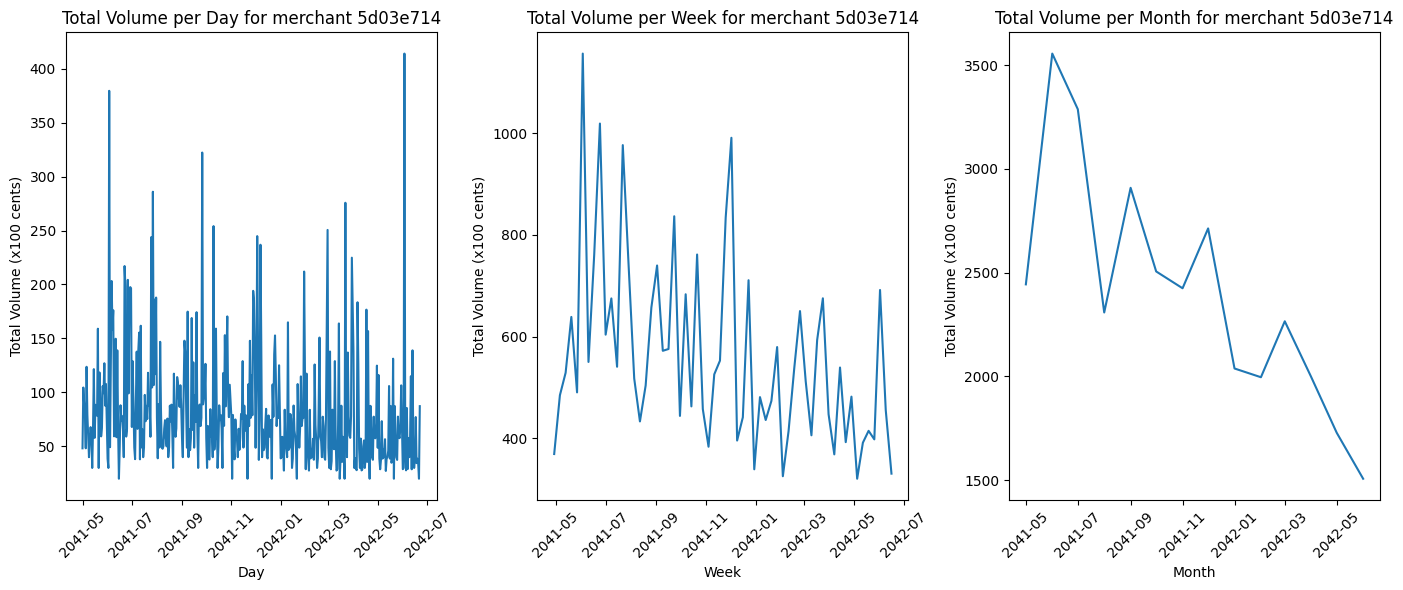

In [18]:
import matplotlib.pyplot as plt
import warnings
store_df = total_df[total_df['merchant'] == '2902587d'].copy()
store_df = store_df.sort_values('date')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    store_df['week'] = store_df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    store_df['day'] = store_df['date'].dt.to_period('D').apply(lambda r: r.start_time)
    store_df['month'] = store_df['date'].dt.to_period('M').apply(lambda r: r.start_time)

fig, axs = plt.subplots(1, 3, figsize=(14, 6), sharex=False)

# Day plot
axs[0].plot(store_df.groupby('day')['total_volume'].sum() / 100)
axs[0].set_xlabel("Day")
axs[0].set_ylabel("Total Volume (x100 cents)")
axs[0].set_title("Total Volume per Day for merchant 5d03e714")
axs[0].tick_params(axis='x', rotation=45)

# Week plot
axs[1].plot(store_df.groupby('week')['total_volume'].sum() / 100)
axs[1].set_xlabel("Week")
axs[1].set_ylabel("Total Volume (x100 cents)")
axs[1].set_title("Total Volume per Week for merchant 5d03e714")
axs[1].tick_params(axis='x', rotation=45)

# Month plot
axs[2].plot(store_df.groupby('month')['total_volume'].sum() / 100)
axs[2].set_xlabel("Month")
axs[2].set_ylabel("Total Volume (x100 cents)")
axs[2].set_title("Total Volume per Month for merchant 5d03e714")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# import numpy as np
# import pandas as pd
# from scipy.signal import periodogram

# # Calculate daily total volume
# daily_vol = store_df.groupby('day')['total_volume'].sum()
# daily_vol = daily_vol.sort_index()

# # Remove zero-volume days for clearer pattern detection (optional)
# # daily_vol = daily_vol[daily_vol > 0]

# # Detrending (optional, depending on your data)
# detrended = daily_vol - daily_vol.rolling(7, min_periods=1, center=True).mean()

# # Use periodogram to find dominant frequencies
# freqs, power = periodogram(detrended.fillna(0), fs=1)  # fs=1 means per day

# # Find peaks in the power spectrum (most prominent seasonalities)
# seasonalities = []
# for idx in np.argsort(power)[::-1]:
#     if freqs[idx] == 0:
#         continue  # skip zero-frequency (mean)
#     period = 1 / freqs[idx]
#     if period > 2 and period < len(daily_vol) / 2:  # Ignore very short or very long periods
#         seasonalities.append((period, power[idx]))
#     if len(seasonalities) >= 3:
#         break

# print("Detected dominant seasonality periods (in days) and their strengths (power):")
# for period, pwr in seasonalities:
#     print(f"Period: {period:.2f} days | Power: {pwr:.2f}")

# print("\nInterpretation: These periods indicate the most prominent recurrence/frequency patterns in the store's total_volume time series.")

e5b01560


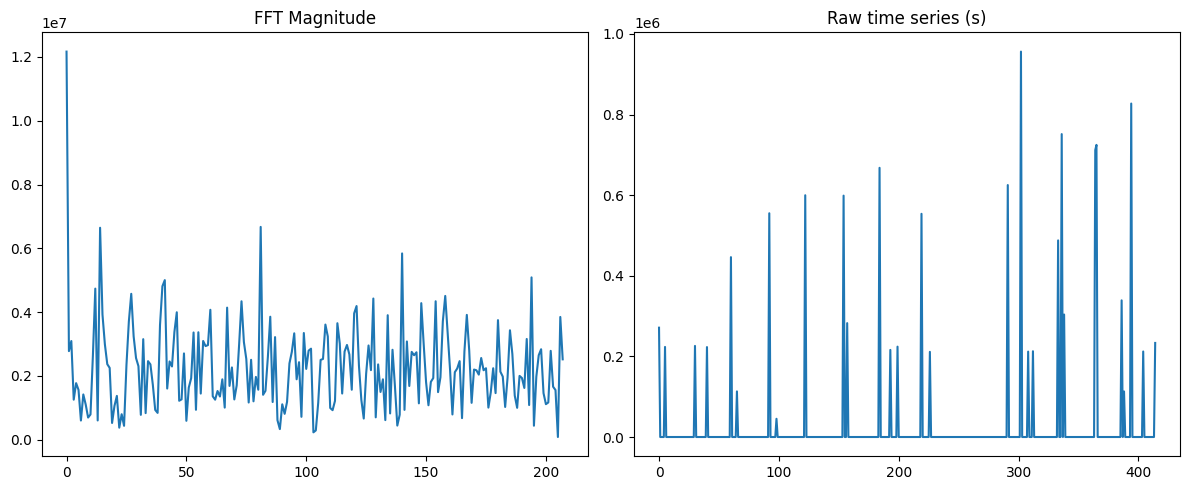

active_ratio                         0.072289
weekly_autocorr                     -0.035964
biweekly_autocorr                   -0.054866
monthly_autocorr                     0.211439
avg_gap_between_payments            14.275862
gap_regularity_share_7d              0.172414
gap_regularity_share_30d                  0.0
cv_volume                            4.212455
cv_weekly                             0.79084
cv_monthly                            0.49204
industry_boost                            0.0
volume_scale                             10.0
total_volume                         12167620
subscription_ratio                        0.0
checkout_ratio                            0.0
payment_link_ratio                        0.0
business_size                           small
industry                    Personal services
dtype: object

In [21]:


def clamp01(x: float) -> float:
    if pd.isna(x):
        return 0.0
    return float(max(0.0, min(1.0, x)))

def coef_var(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        # Warn or quietly return np.nan if only 1 value (prevents degrees of freedom <= 0)
        return np.nan
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))  # Use unbiased estimator (N-1); avoid ddof=0 warning if only one value
    if np.isclose(mu, 0):
        # Prevent divide by zero, emit a clearer NaN
        return np.nan
    return float(sd / mu)

def gap_regularity_share(days: pd.Series, target_gap: int, tol: int = 1) -> float:
    """Share of inter-payment gaps close to a target cadence (e.g. 7 or 30 days)."""
    if len(days) < 6:
        return np.nan
    d = pd.to_datetime(days).sort_values().dropna()
    gaps = d.diff().dt.days.dropna().to_numpy()
    if len(gaps) == 0:
        return np.nan
    return float(np.mean(np.abs(gaps - target_gap) <= tol))

def merchant_recurring_features(group, date_col='date', value_col='total_volume', verbose=False):
    # 1. Sort and prepare
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    s = group[value_col].asfreq('D', fill_value=0)
    # 3. Basic signals
    total_days = len(s)
    active_days = (s > 0).sum()
    active_ratio = active_days / total_days if total_days > 0 else np.nan

    # 4. Autocorrelation (weekly + monthly patterns)
    def safe_autocorr(series, lag):
        if len(series) <= lag or series.nunique() <= 1:
            return np.nan
        return series.autocorr(lag=lag)

    weekly_autocorr = safe_autocorr(s, lag=7)
    biweekly_autocorr = safe_autocorr(s, lag=14)
    monthly_autocorr = safe_autocorr(s, lag=30)

    # 5. Occurrence pattern (how often payments happen)
    avg_gap = np.nan
    payment_days = s[s > 0].index

    if len(payment_days) > 1:
        gaps = np.diff(payment_days.values).astype('timedelta64[D]').astype(int)
        if len(gaps) > 0:
            avg_gap = gaps.mean()
        else:
            avg_gap = np.nan

    mean_val = s.mean()
    std_val = s.std(ddof=1) if len(s) > 1 else np.nan  # ddof=1 for unbiased; nan for single value

    # Prevent divide by zero (and thus suppress RuntimeWarning)
    if np.isclose(mean_val, 0):
        cv = np.nan
    else:
        cv = std_val / mean_val  # coefficient of variation

    total_volume_sum = group['total_volume'].sum()
    subscription_volume_sum = group['subscription_volume'].sum()
    checkout_volume_sum = group['checkout_volume'].sum()
    payment_link_volume_sum = group['payment_link_volume'].sum()

    # Prevent division by zero by checking if total_volume_sum is "close to zero"
    if np.isclose(total_volume_sum, 0):
        subscription_ratio = np.nan
        checkout_ratio = np.nan
        payment_link_ratio = np.nan
    else:
        subscription_ratio = subscription_volume_sum / total_volume_sum
        checkout_ratio = checkout_volume_sum / total_volume_sum
        payment_link_ratio = payment_link_volume_sum / total_volume_sum

    weekly_totals = group['total_volume'].resample('W').sum().to_numpy(dtype=float)
    # Suppress warning by checking length
    # Also prevent divide by zero inside coef_var
    nonzero_weekly = weekly_totals[~np.isclose(weekly_totals, 0)]
    if len(nonzero_weekly) > 1:
        weekly_cv = coef_var(nonzero_weekly)
    else:
        weekly_cv = np.nan

    monthly_totals = group['total_volume'].resample('ME').sum().to_numpy(dtype=float)
    nonzero_monthly = monthly_totals[~np.isclose(monthly_totals, 0)]
    if len(nonzero_monthly) > 1:
        monthly_cv = coef_var(nonzero_monthly)
    else:
        monthly_cv = np.nan

    industry = str(group['industry'].iloc[0]).lower()

    if industry:
        if any(k in industry for k in ['software', 'education', 'membership', 'religion', 'fitness', 'health', 'business services', 'leisure']):
            industry_boost = 1.0
        elif any(k in industry for k in ['retail', 'restaurant', 'food', 'travel', 'events']):
            industry_boost = 0.3
        else:
            industry_boost = 0.0
    else:
        industry_boost = 0.0  # ensure defined

    # Size sanity: avoid tiny merchants dominating by perfect regularity
    tot = total_volume_sum
    # Prevent log of zero/negative. (1+tot) always nonzero/positive as tot>=0
    size = clamp01(np.log10(1 + tot) / np.log10(1 + 10e6))  # 5e6 cents = $50k
    # print(np.log10(1 + tot) / np.log10(1 + 10e6))
    volume_scale = 10 * size

    if verbose:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].plot(np.abs(np.fft.rfft(s)))
        axs[0].set_title("FFT Magnitude")
        axs[1].plot(s.values)
        axs[1].set_title("Raw time series (s)")
        plt.tight_layout()
        plt.show()

    return pd.Series({
        'active_ratio': active_ratio,
        'weekly_autocorr': weekly_autocorr,
        'biweekly_autocorr': biweekly_autocorr,
        'monthly_autocorr': monthly_autocorr,
        'avg_gap_between_payments': avg_gap,
        'gap_regularity_share_7d': gap_regularity_share(group.reset_index()['date'], 7),
        'gap_regularity_share_30d': gap_regularity_share(group.reset_index()['date'], 30),
        'cv_volume': cv,
        'cv_weekly': weekly_cv,
        'cv_monthly': monthly_cv,
        'industry_boost': industry_boost,
        'volume_scale': volume_scale,
        'total_volume': total_volume_sum,
        'subscription_ratio': subscription_ratio,
        'checkout_ratio': checkout_ratio,
        'payment_link_ratio': payment_link_ratio,
        'business_size': group['business_size'].iloc[0],
        'industry': group['industry'].iloc[0]
    })

for merchant_id, group in total_df.groupby('merchant'):
    if merchant_id == 'e5b01560':
        print(merchant_id)
        a = merchant_recurring_features(group, value_col='total_volume', verbose=True)
        display(a)
        break

In [22]:
# Extract features for each merchant and construct a DataFrame with merchants as rows and features as columns
feature_extracted_list = []
merchant_ids = []
for merchant_id, group in total_df.groupby('merchant'):
    # print(merchant_id)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        features = merchant_recurring_features(group, value_col='total_volume')
        feature_extracted_list.append(features)
        merchant_ids.append(merchant_id)

feature_extracted = pd.DataFrame(feature_extracted_list, index=merchant_ids)

In [23]:
feature_extracted.fillna(0, inplace=True)
# high subscription merchants records
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
sub_features

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,cv_volume,cv_weekly,cv_monthly,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry
0015c036,0.184282,0.054903,-0.126946,0.236675,5.492537,0.000000,0.000000,2.243093,0.480836,0.271371,0.0,6.013631,16200,1.000000,0.851852,0.0,small,Others
0018ab92,0.961722,-0.070226,-0.126599,0.210756,1.039900,0.000000,0.000000,0.652504,0.282631,0.106635,0.0,9.140987,2504326,0.989019,0.000000,0.0,small,Others
00314b59,0.035264,-0.034483,-0.035135,0.282269,30.461538,0.000000,0.923077,5.237005,0.000000,0.000000,0.0,6.921577,70000,1.000000,0.000000,0.0,small,Merchandise
004f6060,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,5.233320,4605,1.000000,1.000000,0.0,small,Business services
008f8086,0.118694,-0.010794,-0.038248,0.139047,8.615385,0.025641,0.025641,4.141526,0.878611,0.636564,1.0,7.927370,354126,1.000000,0.000000,0.0,small,Software
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff3afeb5,1.000000,0.218582,0.228385,-0.005477,1.000000,0.000000,0.000000,0.819870,0.432121,0.278286,1.0,10.000000,92285538,0.987602,0.000000,0.0,small,Software
ff42c8f0,0.126214,0.105405,-0.104102,0.172601,8.058824,0.313725,0.000000,2.934673,0.501397,0.290126,1.0,9.670653,5881077,0.979441,0.000000,0.0,small,Business services
ff4b9a9a,0.225182,-0.002742,0.009981,0.270908,4.478261,0.293478,0.000000,2.613428,0.938534,0.316053,0.0,6.970719,75770,1.000000,0.000000,0.0,small,Charity
ff830deb,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,5.182390,4242,1.000000,0.000000,0.0,small,Merchandise


# COSINE based annotating 

In [262]:

from sklearn.metrics.pairwise import cosine_similarity
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
non_sub_features = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]


# Choose feature columns to use for similarity (exclude business_size, industry, and possibly any other categorical)
exclude_cols = ['business_size', 'industry']
feature_cols = [col for col in sub_features.columns if col not in exclude_cols]

sub_vecs = sub_features[feature_cols].values
sub_vecs = np.nan_to_num(sub_vecs, nan=0)

non_sub_vecs = non_sub_features[feature_cols].values
non_sub_vecs = np.nan_to_num(non_sub_vecs, nan=0)

# Compute similarity of each non_subscription merchant to the average feature vector of sub_features
sub_mean_vec = sub_vecs.mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(non_sub_vecs, sub_mean_vec).flatten()

# Attach similarity scores back to the non_sub_features DataFrame
non_sub_features_sim = non_sub_features.copy()
non_sub_features_sim['sim_to_sub'] = cos_sim

# Find top candidates
top_candidates = non_sub_features_sim.sort_values('sim_to_sub', ascending=False).head(10)
top_candidates

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,cv_volume,cv_weekly,cv_monthly,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,sim_to_sub
c54202f6,0.051020,-0.003223,-0.041076,-0.013307,20.578947,0.157895,0.052632,4.931260,0.537086,0.500099,0.3,10.0,17306225,0.0,0.0,0.0,medium,Grocery & food stores,1.0
038b64fc,0.061069,0.030671,-0.036752,-0.021231,17.043478,0.217391,0.000000,5.003490,0.814746,0.669679,1.0,10.0,14517018,0.0,0.0,0.0,small,Business services,1.0
65e72680,0.051576,0.055941,0.022539,-0.040657,20.470588,0.470588,0.058824,5.031866,0.541718,0.607166,0.0,10.0,15443329,0.0,0.0,0.0,small,Merchandise,1.0
6a51cbae,0.039216,-0.030198,0.090230,-0.030722,27.133333,0.066667,0.066667,5.681113,0.636494,0.468282,1.0,10.0,24040000,0.0,0.0,0.0,small,Software,1.0
3d8e8def,0.035088,-0.015330,-0.015662,0.092288,31.000000,0.090909,0.090909,7.580258,1.067883,0.780379,0.3,10.0,22683837,0.0,0.0,0.0,medium,Ticketing & events,1.0
fa0e4868,0.071875,-0.044195,-0.045251,0.092231,14.500000,0.000000,0.090909,4.566893,0.590332,0.284096,0.3,10.0,14022388,0.0,0.0,0.0,small,Travel & lodging,1.0
1a529971,0.055961,-0.031704,0.026283,0.006685,18.636364,0.136364,0.000000,5.559681,0.816859,0.802157,1.0,10.0,13980550,0.0,0.0,0.0,small,Business services,1.0
be90a0a0,0.067647,-0.036047,0.080814,0.090786,15.409091,0.045455,0.045455,4.196009,0.681682,0.498051,1.0,10.0,12414800,0.0,0.0,0.0,small,Business services,1.0
a531be6e,0.070707,-0.025396,0.122937,-0.034324,15.153846,0.000000,0.000000,5.396529,0.960109,0.826691,0.0,10.0,13375415,0.0,0.0,1.0,small,Construction,1.0
bddd0c82,0.072289,-0.035964,-0.054866,0.211439,14.275862,0.172414,0.000000,4.212455,0.790840,0.492040,0.0,10.0,12167620,0.0,0.0,0.0,small,Personal services,1.0


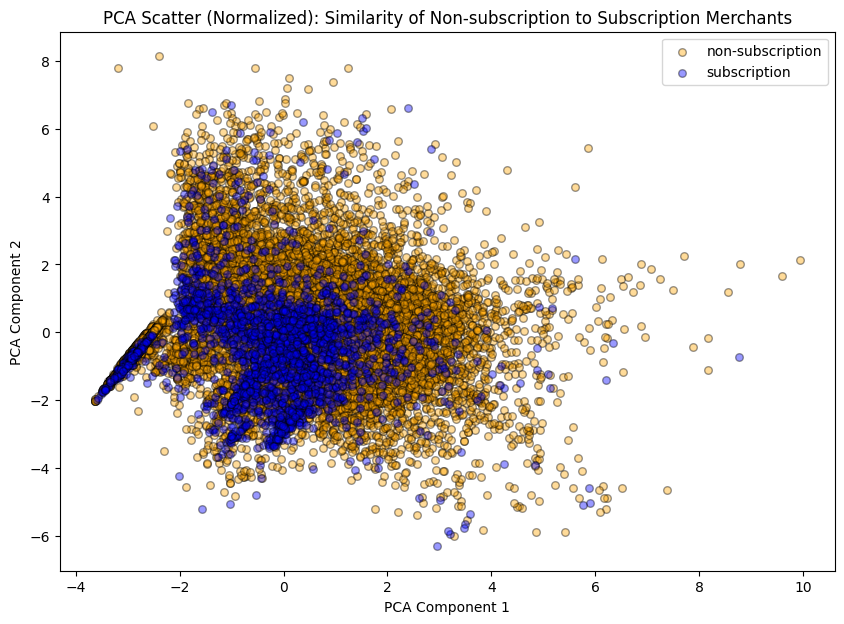

/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/alirezakeshavarzian/ThesisProject/STRIP/myenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,cv_volume,cv_weekly,cv_monthly,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,sim_to_sub
ef4a148a,0.049869,-0.031742,-0.028494,0.326066,21.111111,0.055556,0.444444,5.371451,0.715451,0.535943,1.0,7.506880,179810,0.154919,0.0,0.045520,small,Business services,0.401402
800fad0d,0.042254,-0.036450,-0.036804,0.757044,26.500000,0.000000,0.625000,5.003208,0.326886,0.179370,1.0,8.566670,992358,0.000000,0.0,0.000000,small,Software,0.352278
4ea53f24,0.065491,0.000537,-0.020554,0.082293,15.840000,0.160000,0.120000,4.157971,0.446324,0.380917,1.0,8.819986,1492760,0.190185,0.0,0.028806,small,Business services,0.350763
eb69b5c5,0.038043,-0.035088,-0.036585,0.479730,30.500000,0.000000,1.000000,5.042211,0.000000,0.000000,1.0,5.457994,6615,0.000000,0.0,0.000000,small,Business services,0.340034
47853c4b,0.038961,-0.035211,-0.037037,0.374790,30.600000,0.000000,1.000000,4.982759,0.000000,0.000000,1.0,6.819705,59400,0.000000,0.0,0.000000,small,Business services,0.330055
288447d7,0.046512,-0.042184,-0.043118,0.253245,22.866667,0.000000,0.333333,4.786297,0.494182,0.521657,1.0,7.816456,296154,0.048019,0.0,0.048019,small,Software,0.327046
42dc9106,0.045752,-0.034968,-0.036794,0.320756,25.333333,0.000000,0.500000,5.032216,0.246051,0.246051,1.0,6.713137,50025,0.000000,0.0,0.000000,small,Business services,0.325902
ba503321,0.032911,-0.031670,-0.032270,0.309634,32.833333,0.000000,0.500000,5.466930,0.123393,0.123393,1.0,7.067797,88604,0.000000,0.0,0.000000,small,Education,0.325516
c85d52c1,0.036066,-0.034722,-0.035587,0.291811,30.400000,0.000000,0.900000,5.178339,0.000000,0.000000,1.0,6.203179,21989,0.000000,0.0,0.000000,small,Business services,0.322507
c853dddc,0.074468,-0.041763,-0.045584,0.409736,15.500000,0.000000,0.500000,4.659998,0.528995,0.528995,1.0,5.332106,5400,0.000000,0.0,0.000000,small,Business services,0.321904


In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select sub and non-subscription merchant groups
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
non_sub_features = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]

# Exclude categorical columns for similarity and PCA embedding
exclude_cols = ['business_size', 'industry']
feature_cols = [col for col in sub_features.columns if col not in exclude_cols]

# Prepare DataFrames for normalization and visualization
sub_plot = sub_features[feature_cols].copy()
sub_plot['type'] = 'subscription'
non_sub_plot = non_sub_features[feature_cols].copy()
non_sub_plot['type'] = 'non-subscription'
plot_df = pd.concat([sub_plot, non_sub_plot])

# Normalize feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(plot_df[feature_cols])

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results to dataframe
plot_df['PCA1'] = X_pca[:, 0]
plot_df['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 7))
colors = {'non-subscription': 'orange', 'subscription': 'blue'}
for label, color in colors.items():
    plt.scatter(
        plot_df.loc[plot_df['type'] == label, 'PCA1'], 
        plot_df.loc[plot_df['type'] == label, 'PCA2'],
        label=label,
        alpha=0.4,
        c=color,
        edgecolor="k",
        s=30
    )
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter (Normalized): Similarity of Non-subscription to Subscription Merchants')
plt.legend()
plt.show()

# Additionally, still return the DataFrame of closest non-subs to sub-mean (optional)
from sklearn.metrics.pairwise import cosine_similarity

sub_vecs = scaler.transform(sub_features[feature_cols].values)
non_sub_vecs = scaler.transform(non_sub_features[feature_cols].values)

sub_mean_vec = sub_vecs.mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(non_sub_vecs, sub_mean_vec).flatten()
non_sub_features_sim = non_sub_features.copy()
non_sub_features_sim['sim_to_sub'] = cos_sim

top_candidates = non_sub_features_sim.sort_values('sim_to_sub', ascending=False).head(10)
top_candidates

In [29]:
lowest_date = total_df['date'].min()
highest_date = total_df['date'].max()
print("Lowest date:", lowest_date)
print("Highest date:", highest_date)

import pandas as pd

# Create a full daily date range from lowest to highest date
full_range = pd.date_range(start=lowest_date, end=highest_date, freq='D')

# Get unique merchant IDs
merchant_ids = total_df['merchant'].unique()

# Build a MultiIndex DataFrame for all dates x merchants
full_index = pd.MultiIndex.from_product([full_range, merchant_ids], names=['date', 'merchant'])
full_ts_df = pd.DataFrame(index=full_index).reset_index()

# Merge with your total_df to bring in the actual records
# Assume you want to fill with zeros where data is missing for all columns except 'date' and 'merchant'
merged = pd.merge(
    full_ts_df,
    total_df,
    how='left',
    on=['date', 'merchant']
)

# Fill potentially multiple numeric columns with 0 where missing, leaving object/categorical columns untouched if desired
numeric_cols = merged.select_dtypes(include=['number']).columns.tolist()
# Don't fill 'merchant' and 'date', those are not null
numeric_cols = [col for col in numeric_cols if col not in ['merchant']]

merged[numeric_cols] = merged[numeric_cols].fillna(0)

# If you want to drop any columns filled with all NaNs, or specify fill for other columns, you can do so here.
# The resulting DataFrame `merged` is a time series of merchants by day, with missing intervals filled as zeros

Lowest date: 2041-05-01 00:00:00+00:00
Highest date: 2042-06-22 00:00:00+00:00


In [ ]:

time_series_output = []
merchant_id_list = []
def time_series_df(group,min_date,max_date, date_col='date', value_col='total_volume'):
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    full_range = pd.date_range(start=min_date, end=max_date, freq='D')
    s = group.reindex(full_range)[value_col].fillna(0)
    s.index = full_range
    # INSERT_YOUR_CODE
    s_min = s.min()
    s_max = s.max()
    if s_max > s_min:
        s = (s - s_min) / (s_max - s_min)
    else:
        s = s * 0  # if all values are the same, set to 0
    return s.tolist()


min_date = total_df['date'].min()
max_date = total_df['date'].max()
for merchant_id, group in total_df.groupby('merchant'):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        ts = time_series_df(group,min_date,max_date)
        time_series_output.append(ts)
        merchant_id_list.append(merchant_id)
time_series_output = np.array(time_series_output)


In [ ]:
import rocket.miniROCKET as mr
from sklearn.preprocessing import StandardScaler

time_series_output = time_series_output.astype(np.float32)
parameter = mr.fit(time_series_output,num_features=10000)
dilations, num_features_per_dilation,_, biases = parameter
parameter = dilations, num_features_per_dilation,biases

time_series_tranformed = mr.transform(time_series_output, parameter,'ter')


scaler = StandardScaler()
time_series_transformed_scaled = scaler.fit_transform(time_series_tranformed)

In [ ]:
from sklearn.preprocessing import StandardScaler

good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index':'merchant'})['merchant'].tolist()
good_sub_merchant_indices = [merchant_id_list.index(m) for m in good_sub_merchant if m in merchant_id_list]
# Here's an improved and bug-annotated rewrite:
good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()
unknown_merchant = feature_extracted[feature_extracted['subscription_ratio'] < 0.2].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()

np.random.seed(None)
#PCA
n_components = 2
pca = PCA(n_components=n_components)
time_series_pca = pca.fit_transform(time_series_transformed_scaled)
print(f"PCA explained variance ratio (first {n_components}: {pca.explained_variance_ratio_}")

x_subscripted_feature = []
y_subscripted = []
for m in good_sub_merchant:
    f = feature_extracted.loc[m].values[:12].tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    # x_subscripted_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_subscripted_feature.append(f)
    y_subscripted.append('subscription')

x_unknown_feature = []
y_unknown = []
for m in unknown_merchant:
    f = feature_extracted.loc[m].values[:12].tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    # x_unknown_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_unknown_feature.append(f)
    y_unknown.append('non-subscription')

x_subscripted_feature = np.array(x_subscripted_feature)
y_subscripted = np.array(y_subscripted)

x_unknown_feature = np.array(x_unknown_feature)
y_unknown = np.array(y_unknown)

print('===============================================')
print('Total number of subscription merchants: ', x_subscripted_feature.shape)

print('Total number of non-subscription merchants: ', x_unknown_feature.shape)
# dataset creation

indices_sub_train = np.random.choice(range(len(x_subscripted_feature)), size=int(len(x_subscripted_feature)*0.7), replace=False)
indices_sub_test = [i for i in range(len(x_subscripted_feature)) if i not in indices_sub_train]


number_of_non_sub = min(int(len(x_subscripted_feature)*3), len(x_unknown_feature))  # Avoid overflow; don't pick more samples than possible.
indices_non_sub_train = np.random.choice(range(len(x_unknown_feature)),size=int(number_of_non_sub*0.7),replace=False)
rest_of_unknown = set(np.arange(len(x_unknown_feature))) - set(indices_non_sub_train)
# If remaining is not enough, sample with replacement (guards against ValueError)
size_for_non_sub_test = int(number_of_non_sub*0.3)
if len(rest_of_unknown) >= size_for_non_sub_test:
    indices_non_sub_test = np.random.choice(list(rest_of_unknown), size=size_for_non_sub_test, replace=False)
else:
    indices_non_sub_test = np.random.choice(range(len(x_unknown_feature)), size=size_for_non_sub_test, replace=True)

x_train = np.concatenate([x_subscripted_feature[indices_sub_train], x_unknown_feature[indices_non_sub_train]])
y_train = np.concatenate([y_subscripted[indices_sub_train], y_unknown[indices_non_sub_train]])
y_test = np.concatenate([y_subscripted[indices_sub_test], y_unknown[indices_non_sub_test]])
x_test = np.concatenate([x_subscripted_feature[indices_sub_test], x_unknown_feature[indices_non_sub_test]])
y_test = np.concatenate([y_subscripted[indices_sub_test], y_unknown[indices_non_sub_test]])



print('X_test shape: ',x_test.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape: ', x_test.shape)
print('y_test shape: ', y_test.shape)

#scaling 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


ridge_classifier.fit(x_train, y_train)
ridge_classifier = RidgeClassifier(alpha=0.1, class_weight='balanced')
ridge_classifier.fit(x_train, y_train)


PCA explained variance ratio (first 2: [0.8429552  0.07325508]
Total number of subscription merchants:  (2675, 12)
Total number of non-subscription merchants:  (19979, 12)
X_test shape:  (3210, 12)
X_train shape:  (7489, 12)
y_train shape:  (7489,)
X_train shape:  (7489, 12)
y_train shape:  (7489,)
X_test shape:  (3210, 12)
y_test shape:  (3210,)


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,'balanced'
,solver,'auto'
,positive,False
,random_state,None


Accuracy test:  0.7588785046728972 Accuracy train:  0.7587127787421551


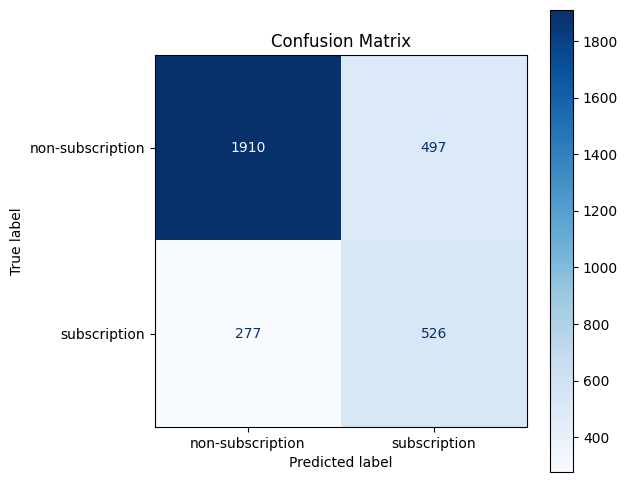

In [256]:
accuracy_test, accuracy_train = ridge_classifier.score(x_test, y_test), ridge_classifier.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = ridge_classifier.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ridge_classifier.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

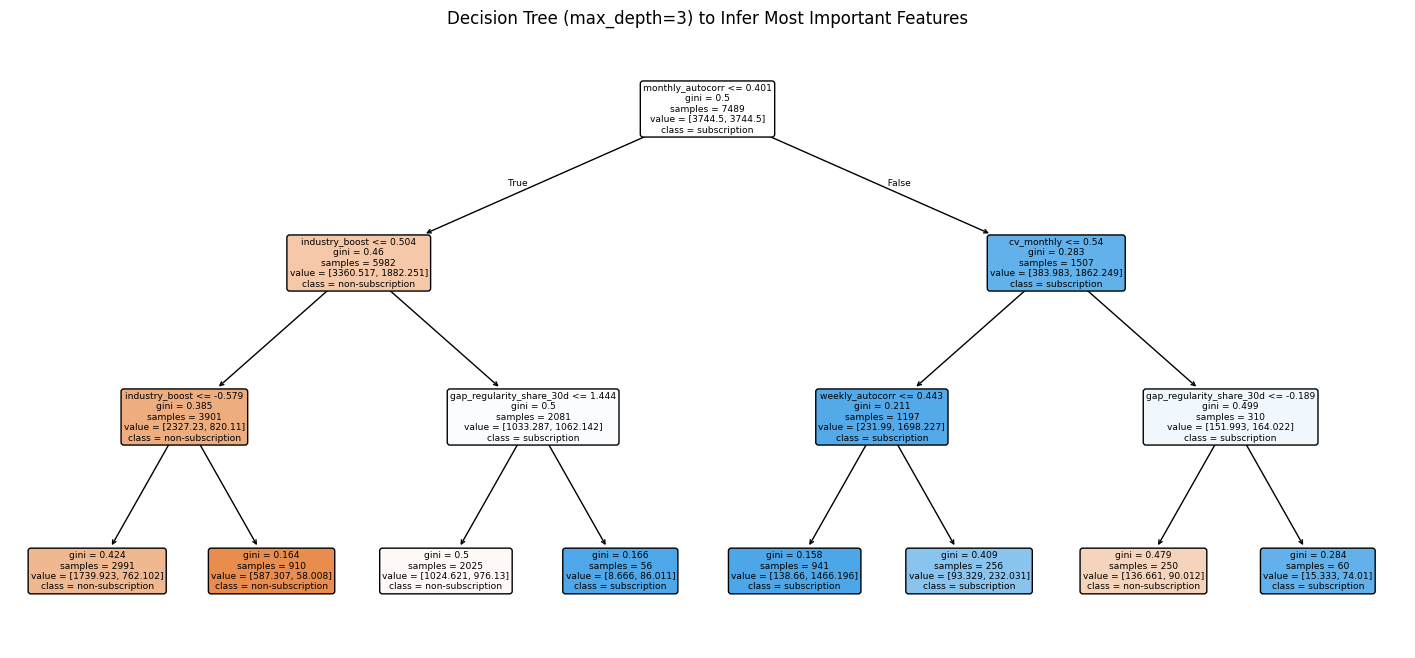

Accuracy test:  0.8171339563862928 Accuracy train:  0.8228067832821472
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.6662
Feature industry_boost: Importance = 0.1917
Feature cv_monthly: Importance = 0.0678
Feature gap_regularity_share_30d: Importance = 0.0535
Feature weekly_autocorr: Importance = 0.0208
Feature volume_scale: Importance = 0.0000
Feature cv_weekly: Importance = 0.0000
Feature cv_volume: Importance = 0.0000
Feature gap_regularity_share_7d: Importance = 0.0000
Feature avg_gap_between_payments: Importance = 0.0000
Feature biweekly_autocorr: Importance = 0.0000
Feature active_ratio: Importance = 0.0000


In [257]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Train a decision tree classifier on the training data
dtree = DecisionTreeClassifier(max_depth=3, random_state=None, class_weight='balanced')
dtree.fit(x_train, y_train)

# Plot the decision tree to visualize feature importance and splits
features_name = feature_extracted.columns.tolist()[:12]
plt.figure(figsize=(18, 8))
plot_tree(dtree, 
          feature_names=features_name, 
          class_names=[str(c) for c in dtree.classes_], 
          filled=True, 

          rounded=True)
plt.title("Decision Tree (max_depth=3) to Infer Most Important Features")
plt.show()

pred = dtree.predict(x_test)
accuracy_test, accuracy_train = dtree.score(x_test, y_test), dtree.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
# Print feature importances
importances = dtree.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

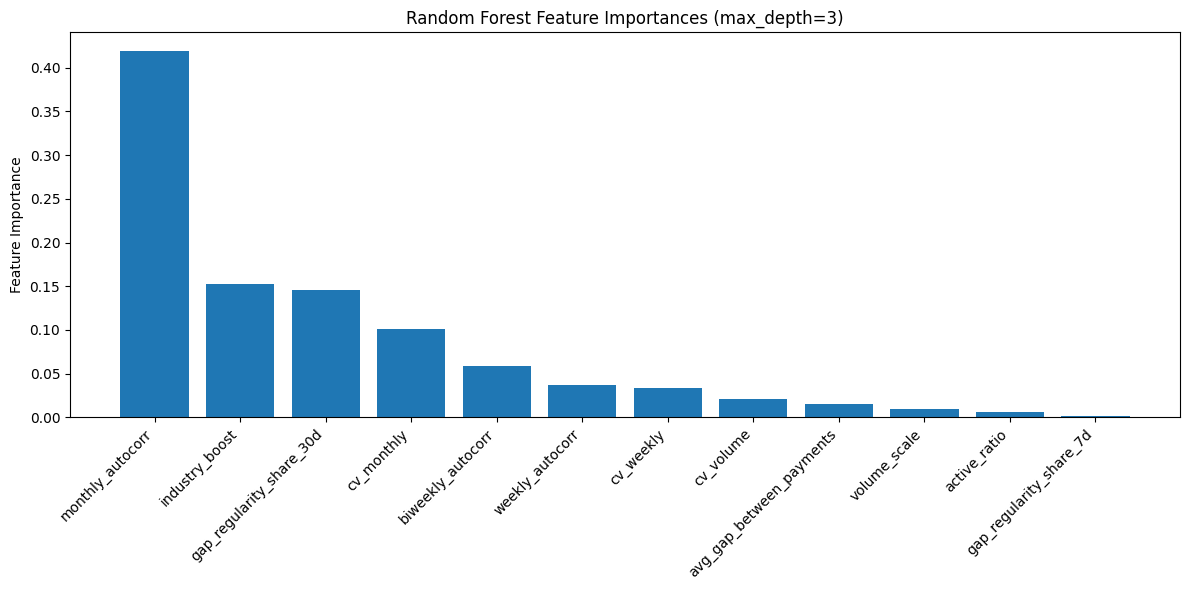

Accuracy test:  0.8015576323987539 Accuracy train:  0.8010415275737749
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.4196
Feature industry_boost: Importance = 0.1522
Feature gap_regularity_share_30d: Importance = 0.1455
Feature cv_monthly: Importance = 0.1005
Feature biweekly_autocorr: Importance = 0.0582
Feature weekly_autocorr: Importance = 0.0374
Feature cv_weekly: Importance = 0.0331
Feature cv_volume: Importance = 0.0204
Feature avg_gap_between_payments: Importance = 0.0157
Feature volume_scale: Importance = 0.0096
Feature active_ratio: Importance = 0.0062
Feature gap_regularity_share_7d: Importance = 0.0015


In [258]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a random forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=None, class_weight='balanced')
rf.fit(x_train, y_train)

# Feature names for plotting/importances
features_name = feature_extracted.columns.tolist()[:12]

# Plot feature importances
importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features_name)), importances[sorted_indices], align='center')
plt.xticks(range(len(features_name)), [features_name[i] for i in sorted_indices], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances (max_depth=3)')
plt.tight_layout()
plt.show()

# Predict and print accuracies
pred = rf.predict(x_test)
accuracy_test = rf.score(x_test, y_test)
accuracy_train = rf.score(x_train, y_train)
print('Accuracy test: ', accuracy_test, 'Accuracy train: ', accuracy_train)

# Print feature importances sorted
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")